In [8]:
# in this script I compute c_k and C_omega_2 from balance of k and omega equations, respectively
# tkaen from ~/noback/pycalc-les/pytorch-k-eq/pl_vist_ML-c_k-c_omega_2000_5200-plus-units.py


# it is used in the paper 
#L. Davidson<br>
#"Using Physical Informed Neural Network (PINN) to Improve a k-omega Turbulence Model",
#<i> ERCOFTAC Symposium on Engineering Turbulence Modelling and Measurements (ETMM-15)</i>, Dubrovnik on 22-24 September 2025.

import numpy as np
from numpy import linalg as LA
import math as m
import os
import sys
from matplotlib.image import imread
import matplotlib.pyplot as plt
from matplotlib import rcParams # for changing default values
import scipy.io as sio
from scipy.optimize import minimize
import timeit
import torch
import random
import torch.nn as nn
import torch.optim as optim
from scipy.integrate import odeint
from torch.autograd import grad
import torch.optim.lr_scheduler as lr_scheduler


plt.close('all')
plt.interactive(True)
# set all fontsizes to 12
rcParams["font.size"] = 16
rcParams["axes.axisbelow"] = True # make sure grid is behind plots

prand_om = 2
c_omega_2=3./40.


viscos_5200 = 1/5200
# load k-omega grid 5200
#name = '../channel-5200-half-channel/'
kom_data = np.loadtxt('y_u_k_om_uv_5200-RANS-half-channel.txt')
y_kom_5200 = kom_data[:,0]
u_kom_5200 = kom_data[:,1]
k_kom_5200 = kom_data[:,2]
om_kom_5200 = kom_data[:,3]
vist= k_kom_5200/om_kom_5200
vist_kom_5200 = vist
y= y_kom_5200


#vist_ML_5200 = np.loadtxt('vist_pred-PINN-from-vist-diffusion-pinn-5200-plus-units-load-5-cells.txt')
vist_ML_5200 = np.loadtxt('vist_predicted.txt')

vist_ML_5200_org  = vist_ML_5200 

# insert zeros
j=5
zeros_list = np.zeros(j,dtype=int).tolist()
vist_ML_5200 = np.insert(vist_ML_5200[j-5:], zeros_list, j*[0])  # the length of c_omega_2 is nj-5
# note that I interpolate at y NOT yplus, since prand_k, c_k, c_omega are functions of y/delta
vist_ML_5200[0:j] = np.interp(y_kom_5200[0:j], [0,y_kom_5200[j]],[0,vist_ML_5200[j]])

#np.savetxt('vist_pred-PINN-from-vist-diffusion-pinn-5200-plus-units-load-5-cells-fixed.txt',vist_ML_5200)

vist_ML_5200 = vist_ML_5200/5200



prand_k_5200 = np.minimum(vist/vist_ML_5200,2)
prand_k_5200_no_limit = vist/vist_ML_5200
prand_k_5200[33:] = 2
#np.savetxt('prand_k_5200-plus-units-from-balance.txt',prand_k_5200)
#np.savetxt('prand_k_5200-plus-units-from-balance-no-limit.txt',prand_k_5200_no_limit)

yplus_kom_5200 = y_kom_5200*5200

# load DNS data
# Re = 5200
#  % % y/delta  y^+ U dU/dy W    P        
DNS_mean=np.genfromtxt("LM_Channel_5200_mean_prof.dat",comments="%")
y_DNS=DNS_mean[:,0];
yplus_DNS=DNS_mean[:,1];
u_DNS=DNS_mean[:,2];
dudy_DNS=np.gradient(u_DNS,y_DNS)

# Re = 5200
DNS_stress=np.genfromtxt("LM_Channel_5200_vel_fluc_prof.dat",comments="%")
y_DNS=DNS_stress[:,0];
u2_DNS=DNS_stress[:,2];
v2_DNS=DNS_stress[:,3];
w2_DNS=DNS_stress[:,4];
uv_DNS=DNS_stress[:,5];
k_DNS=0.5*(u2_DNS+v2_DNS+w2_DNS)

#y/delta y^+ Prod Turb_Transport Viscous_Transport Pressure_Strain Pressure_Transport Viscous_Dissipation  Balance
DNS_k_terms=np.genfromtxt("LM_Channel_5200_RSTE_k_prof.dat",comments="%")

diss_DNS=DNS_k_terms[:,7]/viscos_5200
Pk_DNS=DNS_k_terms[:,2]/viscos_5200
diff_DNS=DNS_k_terms[:,3]/viscos_5200

k_DNS_5200 = np.interp(y_kom_5200, y_DNS, k_DNS)
Pk_DNS_5200 = np.interp(y_kom_5200, y_DNS, Pk_DNS)
diss_DNS_5200 = np.interp(y_kom_5200, y_DNS, diss_DNS)
diff_DNS_5200 = np.interp(y_kom_5200, y_DNS, diff_DNS)

## limit the ratio of k_DNS/k_kom. 
k_ratio = np.minimum(k_DNS_5200/k_kom_5200,5)
## new k_DNS
k_DNS_5200 = k_ratio*k_kom_5200 # This avoids very large 0.09*k*omega = diss near the wall

# set a new omega which satisfies vist_kom = k_om/om_kom with k=k_DNS
om_kom_5200_DNS = k_DNS_5200/vist_kom_5200

# balance k eq
#        differential_equation_loss = diff_DNS  + (Pk_DNS - c_k_pred*0.09*k_DNS*om_kom
c_k_pred_5200 = ( diff_DNS_5200  + Pk_DNS_5200)/(0.09*k_DNS_5200*om_kom_5200_DNS)

c_k_pred_5200 = np.minimum(c_k_pred_5200,1)


#np.savetxt('c_k_pred_5200-plus-units-from-balance.txt',c_k_pred_5200)



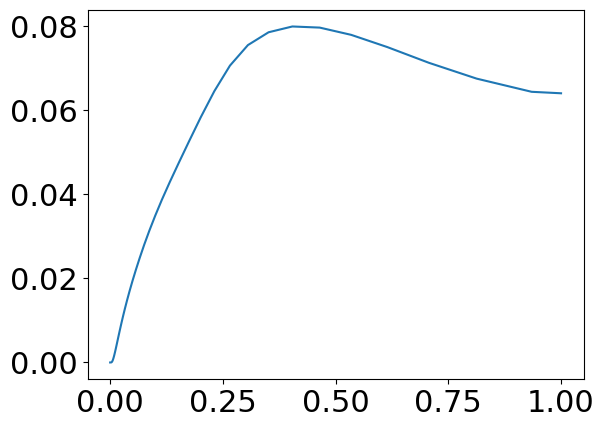


---iter:  1, wall shear stress: 8.99e-08,  tau_w_target=1.00e+00


---iter:  1, res u: 1.00e+00,  res k=3.42e+00


---iter:  2, wall shear stress: 1.65e-07,  tau_w_target=1.00e+00


---iter:  2, res u: 1.00e+00,  res k=3.34e+00


---iter:  3, wall shear stress: 2.31e-07,  tau_w_target=1.00e+00


---iter:  3, res u: 1.00e+00,  res k=3.29e+00


---iter:  4, wall shear stress: 2.91e-07,  tau_w_target=1.00e+00


---iter:  4, res u: 1.00e+00,  res k=3.26e+00


---iter:  5, wall shear stress: 3.48e-07,  tau_w_target=1.00e+00


---iter:  5, res u: 1.00e+00,  res k=3.25e+00


---iter:  6, wall shear stress: 4.02e-07,  tau_w_target=1.00e+00


---iter:  6, res u: 1.00e+00,  res k=3.24e+00


---iter:  7, wall shear stress: 4.55e-07,  tau_w_target=1.00e+00


---iter:  7, res u: 1.00e+00,  res k=3.23e+00


---iter:  8, wall shear stress: 5.06e-07,  tau_w_target=1.00e+00


---iter:  8, res u: 1.00e+00,  res k=3.22e+00


---iter:  9, wall shear stress: 5.57e-07,  tau_w_target=1.00e+00


---iter:  9,

In [9]:
import numpy as np
import torch
import sys
import time
import torch.nn as nn
import torch.optim as optim
import torch.optim.lr_scheduler as lr_scheduler
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
#from sklearn.discriminant_analysis import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from random import randrange
from joblib import dump, load

#########  The neural network modules: start ################################
class MyNet(nn.Module):

    def __init__(self):
        super().__init__()
        self.input   = nn.Linear(2, 10)  #axis 0: number of inputs
        self.hidden1 = nn.Linear(10, 10)
        self.hidden2 = nn.Linear(10, 1)  #axis 1: number of outputs

    def forward(self, x):
        x = nn.functional.relu(self.input(x))
        x = nn.functional.relu(self.hidden1(x))
        x = self.hidden2(x)

        return x

# TDMA solver
def tdma(a,b,c,d,phi,ni):
   import numpy as np

   nim1=ni-1
   p=np.zeros(ni+1)
   q=np.zeros(ni+1)
   q[0]=phi[0]
   for i in range(1,ni):

#            calculate coefficients of recurrence formula                      
      term= (a[i]-c[i]*p[i-1])
      if abs(term)<1.e-10:
         term=1.e-10
      p[i]= b[i]/term
      q[i]= (d[i]+c[i]*q[i-1])/term
#         obtain new phi@s                                       
   for ii in range(1,ni):
       i= ni-ii
#      print('i,ii=',i,ii)
       phi[i]= p[i]*phi[i+1]+q[i]

   return phi


plt.interactive(True)

plt.close('all')

#

# exemple of 1d Channel flow with a k-epsa model. Re=u_tau*h/nu=5200 (h=half 
# channel height).
#
# Discretization described in detail in
# http://www.tfd.chalmers.se/~lada/comp_fluid_dynamics/

# Use NN model or no
NN_bool = False
#NN_bool = True

# max number of iterations
maxit=25000
maxit=50000
#maxit=2

plt.rcParams.update({'font.size': 22})

# friction velocity u_*=1
# half channel width=1
#

# create the grid

# nj=31 # coarse grid
# nj=99 # fine grid
# njm1=nj-1
# yfac=1.6 # coarse grid
# yfac=1.15 # fine grid
# dy=0.1
# yc=np.zeros(nj)
# delta_y=np.zeros(nj)
# yc[0]=0.
# for j in range(1,int((nj+1)/2)):
#     yc[j]=yc[j-1]+dy
#     dy=yfac*dy


# ymax= yc[int((nj-1)/2)]

# # cell faces
# for j in range(0,int((nj+1)/2)):
#    yc[j]=yc[j]/ymax
#    yc[nj-j-1]=2.-yc[j]
# yc[-1]=2.

# # cell centres
# yp=np.zeros(nj+1)
# for j in range(1,nj):
#    yp[j]=0.5*(yc[j]+yc[j-1])
# yp[-1]=yc[-1]

nj = 99  # still fine grid, but now only half
yfac = 1.15
dy = 0.1
yc = np.zeros(nj)
yc[0] = 0.
delta_y=np.zeros(nj)

for j in range(1, nj):
    yc[j] = yc[j-1] + dy
    dy = yfac * dy

# Normalize so that top boundary (centerline) is y=1
ymax = yc[-1]
yc = yc / ymax

# cell centers
yp = np.zeros(nj+1)
for j in range(1, nj):
    yp[j] = 0.5 * (yc[j] + yc[j-1]) 

yp[0]=yc[0]
yp[-1]=yc[-1]


# viscosity
viscos=1/5200

############# 5200 ###############
DNS_k_terms=np.genfromtxt("LM_Channel_5200_RSTE_k_prof.dat",comments="%")

y_DNS = DNS_k_terms[:,0]
diss_DNS=DNS_k_terms[:,7]
Pk_DNS=DNS_k_terms[:,2]
Pk_DNS_interp   = 1/viscos*np.interp(yp, y_DNS, Pk_DNS)
diss_DNS_interp = 1/viscos*np.abs(np.interp(yp, y_DNS, diss_DNS))
eps = diss_DNS_interp

############# 2000 ###############
# load DNS data
#DNS_k_terms=np.genfromtxt("Re2000_bal_k.dat",comments="%")

#y_DNS = DNS_k_terms[:,0]
#diss_DNS=DNS_k_terms[:,2]
#Pk_DNS=DNS_k_terms[:,3]
#Pk_DNS_interp   = 1/viscos*np.interp(yp, y_DNS, Pk_DNS)
#diss_DNS_interp = 1/viscos*np.abs(np.interp(yp, y_DNS, diss_DNS))
#eps = diss_DNS_interp



# under-relaxation
urf=0.5

# plot k for each iteration at node jmon
jmon=8 

# turbulent constants 
c_eps_1=1.5
c_eps_2=1.9

# Prandtl number 
prand_eps=1.4
# prandtl_y=np.loadtxt('prand_k_5200-plus-units-from-balance.txt')
# prandtl_k=prandtl_y[:,1]
# y_=prandtl_y[:,0]

vistload=np.loadtxt('vist-y.txt')
vist=vistload[:,0]
y_=vistload[:,1]

# plt.plot(y_,vist)
# plt.show(block=True)

cmu=0.09

small=1.e-10
great=1.e10

# initialaze
u=np.zeros(nj+1)
k=np.ones(nj+1)*1.e-4
y=np.zeros(nj+1)
#eps=np.ones(nj+1)*1.e-5
# vist=np.ones(nj+1)*100.*viscos
vist=np.interp(yp,y_,vist)


plt.plot(yp,vist)
plt.show(block=True)

dn=np.zeros(nj+1)
ds=np.zeros(nj+1)
dy_s=np.zeros(nj+1)
fy=np.zeros(nj+1)
f2=np.zeros(nj+1)
fmu=np.zeros(nj+1)
tau_w=np.zeros(maxit)
k_iter=np.zeros(maxit)
eps_iter=np.zeros(maxit)
dudy=np.gradient(u,yp)
prand_k=np.ones(nj+1)


# prand_k=np.interp(yp,y_,prandtl_k)
# load NN model
if NN_bool:
   NN = torch.load('model-neural-k-omega-f_2.pth',weights_only=False)
   scaler_yplus = load('scaler-yplus-k-omega-f_2.bin')
   scaler_ystar = load('scaler-ystar-k-omega-f_2.bin')


   yplus_min,yplus_max,ystar_min,ystar_max,f2_min,f2_max = np.loadtxt('min-max-model-f_2.txt')

# do a loop over all nodes (except the boundary nodes)
for j in range(1,nj):

# compute dy_s
   dy_s[j]=yp[j]-yp[j-1]

# compute dy_n
   dy_n=yp[j+1]-yp[j]

# compute deltay
   delta_y[j]=yc[j]-yc[j-1]
 
   dn[j]=1./dy_n
   ds[j]=1./dy_s[j]

# interpolation factor
   del1=yc[j]-yp[j]
   del2=yp[j+1]-yc[j]
   fy[j]=del1/(del1+del2)

vist[0]=0.
vist[-1]=0.
k[0]=0.
k[-1]=0.


su=np.zeros(nj+1)
sp=np.zeros(nj+1)
an=np.zeros(nj+1)
as1=np.zeros(nj+1)
ap=np.zeros(nj+1)
# do max. maxit iterations
for n in range(1,maxit):

    if NN_bool:
       ustar=(viscos*u[1]/yp[1])**0.5
       yplus = np.minimum(yp,2-yp)*ustar/viscos 
       ueps=(eps*viscos)**0.25
       ystar=ueps*np.minimum(yp,2-yp)/viscos

# count values larger/smaller than max/min
       yplus_min_number= (yplus< yplus_min).sum()
       yplus_max_number= (yplus > yplus_max).sum()

       print('yplus_min_number',yplus_min_number)
       print('yplus_max_number',yplus_max_number)

       ystar_min_number= (ystar< ystar_min).sum()
       ystar_max_number= (ystar > ystar_max).sum()

       print('ystar_min_number',ystar_min_number)
       print('ystar_max_number',ystar_max_number)

# set limits
       yplus=np.minimum(yplus,yplus_max)
       yplus=np.maximum(yplus,yplus_min)
       ystar=np.minimum(ystar,ystar_max)
       ystar=np.maximum(ystar,ystar_min)

# re-shape
       yplus_shape= yplus.reshape(-1,1)
       ystar_shape= ystar.reshape(-1,1)
   
       X=np.zeros((len(dudy),2))
       X[:,0] = scaler_yplus.transform(yplus_shape)[:,0]
       X[:,1] = scaler_ystar.transform(ystar_shape)[:,0]

# convert the numpy arrays to PyTorch tensors with float32 data type
       X= torch.tensor(X, dtype=torch.float32)

       preds = NN(X)

#transform from tensor to numpy
       f2_NN = preds.detach().numpy()

# count values larger/smaller than max/min
       f2_min_number= (f2_NN <= f2_min).sum()
       f2_max_number= (f2_NN >= f2_max).sum()

       print('f2_min_number',f2_min_number)
       print('f2_max_number',f2_max_number)

# set limits
       f2_NN=np.minimum(f2_NN,f2_max)
       f2_NN=np.maximum(f2_NN,f2_min)


# solve u

    for j in range(1,nj):

# driving pressure gradient
      su[j]=delta_y[j]

      sp[j]=0.

# interpolate turbulent viscosity to faces
      vist_n=fy[j]*vist[j+1]+(1-fy[j])*vist[j]
      vist_s=fy[j-1]*vist[j]+(1-fy[j-1])*vist[j-1]

# compute an & as
      an[j]=(vist_n+viscos)*dn[j]
      as1[j]=(vist_s+viscos)*ds[j]

# boundary conditions for u
    # u[0]=0.
    # u[-1]=0.
    u[0] = 0.              # no-slip wall
    u[-1] = u[-2]          # symmetry: du/dy = 0


    res_u = 0
    for j in range(1,nj):
# compute ap
      ap[j]=an[j]+as1[j]-sp[j]

# under-relaxate
      ap[j]= ap[j]/urf
      su[j]= su[j]+(1.0-urf)*ap[j]*u[j]

      res_u += abs(an[j]*u[j+1]+as1[j]*u[j-1]+su[j]-ap[j]*u[j])
# use Gauss-Seidel
#     u[j]=(an[j]*u[j+1]+as1[j]*u[j-1]+su[j])/ap[j]
# use TDMA
    u=tdma(ap,an,as1,su,u,nj)

# monitor the development of u_tau in node jmon
    tau_w[n]=viscos*u[1]/yp[1]

# print iteration info
    tau_target=1
    print(f"\n{'---iter: '}{n:2d}, {'wall shear stress: '}{tau_w[n]:.2e},{'  tau_w_target='}{tau_target:.2e}\n")


# check for convergence (when converged, the wall shear stress must be one)
    ntot=n
    if abs(tau_w[n]-1) < 0.001:
# do at least 1000 iter 
        if n > 1000:
           print('Converged!')
           break

# solve k
    res_k = 0
# monitor the development of k in node jmon
    k_iter[n]=k[jmon]

    dudy=np.gradient(u,yp)
# fix boundaries
    dudy[0]=dudy[1]
    dudy[-1]=dudy[-2]

    dudy2=dudy**2
    for j in range(1,nj):

      dist =  np.minimum(yp[j],2-yp[j])
      ueps=(eps[j]*viscos)**0.25
      ystar=ueps*dist/viscos
      rt=k[j]**2/eps[j]/viscos
      if NN_bool:
         f2[j]=f2_NN[j,0]
      else:
         f2[j]=((1.-np.exp(-ystar/3.1))**2)*(1.-0.3*np.exp(-(rt/6.5)**2))
      fmu[j]=((1.-np.exp(-ystar/14.))**2)*(1.+5./rt**0.75*np.exp(-(rt/200.)**2))
      fmu[j]=np.minimum(fmu[j],1.)

# compute viscosity
    #   vist_new = cmu*fmu[j]*k[j]**2/eps[j]
    #   vist[j] = vist_new*urf + (1-urf)*vist[j]

########## Old ###########
# production term
#      su[j]=vist[j]*dudy2[j]*delta_y[j]

# dissipation term
#      sp[j]=-eps[j]/k[j]*delta_y[j]
  
############ New ##############    
      su[j] = Pk_DNS_interp[j] * delta_y[j]       # DNS production
      sp[j] = -diss_DNS_interp[j]/(k[j]+1e-10) * delta_y[j]    # DNS dissipation
      
########### New 2 ###############
      
      #su[j] = (Pk_DNS_interp[j] - diss_DNS_interp[j]) * delta_y[j]
      #sp[j] = 0.

# compute an & as
      vist_n=fy[j]*vist[j+1]+(1.-fy[j])*vist[j]
      an[j]=(vist_n/prand_k[j]+viscos)*dn[j]
      vist_s=fy[j-1]*vist[j]+(1.-fy[j-1])*vist[j-1]
      as1[j]=(vist_s/prand_k[j]+viscos)*ds[j]

# boundary conditions for k
    # k[0]=0.
    # k[-1]=0.
    k[0] = 0.              # wall condition
    k[-1] = k[-2]          # symmetry: dk/dy = 0


    for j in range(1,nj):
# compute ap
      ap[j]=an[j]+as1[j]-sp[j]

# under-relaxate
      ap[j]= ap[j]/urf
      su[j]= su[j]+(1.-urf)*ap[j]*k[j]

      res_k += abs(an[j]*k[j+1]+as1[j]*k[j-1]+su[j]-ap[j]*k[j])
# use Gauss-Seidel
#     k[j]=(an[j]*k[j+1]+as1[j]*k[j-1]+su[j])/ap[j]

# use TDMA
    k=tdma(ap,an,as1,su,k,nj)

#****** solve eps-eq.
#    res_eps = 0
#    eps_iter[n]=eps[jmon]

#    for j in range(1,nj):
# compute an & as
#      vist_n=fy[j]*vist[j+1]+(1.-fy[j])*vist[j]
#      an[j]=(vist_n/prand_eps+viscos)*dn[j]
#      vist_s=fy[j-1]*vist[j]+(1.-fy[j-1])*vist[j-1]
#      as1[j]=(vist_s/prand_eps+viscos)*ds[j]

################# Old ###########
# production term
#      su[j]=c_eps_1*cmu*fmu[j]*dudy2[j]*k[j]*delta_y[j]
# su3d=su3d+c_eps_1*cmu*fmu3d*gen*k3d*vol

# dissipation term
#      sp[j]=-c_eps_2*f2[j]*eps[j]*delta_y[j]/k[j]
################# New ##############
    #su[j] = c_eps_1 * (Pk_DNS_interp[j] * diss_DNS_interp[j] / k[j]) * delta_y[j]
    #sp[j] = -c_eps_2 * diss_DNS_interp[j] * delta_y[j] / k[j]   

# b.c. south wall
#    dy=yp[1]
#    eps_wall=2*viscos*k[1]/yp[1]**2  # cell 0 is outside the domain
#    sp[1]=-great
#    su[1]=great*eps_wall
    



# b.c. north wall
    # dy=yc[-1]-yp[-2] # cell yp[-1] is outside the domain
    # eps_wall=2*viscos*k[-2]/dy**2 
    # sp[-2]=-great
    # su[-2]=great*eps_wall

    # b.c. north wall (centerline symmetry)
#    eps[-1] = eps[-2]

#    for j in range(1,nj):
# compute ap
#      ap[j]=an[j]+as1[j]-sp[j]

# under-relaxate
#      ap[j]= ap[j]/urf
#      su[j]= su[j]+(1.-urf)*ap[j]*eps[j]

#      if j != 1 and j != nj-1: # omit the wall-adjacent cells where eps is set
#         res_eps += abs(an[j]*eps[j+1]+as1[j]*eps[j-1]+su[j]-ap[j]*eps[j])
# use Gauss-Seidel
#     eps[j]=(an[j]*eps[j+1]+as1[j]*eps[j-1]+su[j])/ap[j]

# use TDMA
#    eps=tdma(ap,an,as1,su,eps,nj)

# print residuals
    print(f"\n{'---iter: '}{n:2d}, {'res u: '}{res_u:.2e},{'  res k='}{res_k:.2e}\n")

DNS_mean=np.genfromtxt("LM_Channel_5200_mean_prof.dat",comments="%")
y_DNS=DNS_mean[:,0];
yplus_DNS=DNS_mean[:,1];
u_DNS=DNS_mean[:,2];

DNS_stress=np.genfromtxt("LM_Channel_5200_vel_fluc_prof.dat",comments="%")
u2DNS=DNS_stress[:,2];
v2DNS=DNS_stress[:,3];
w2DNS=DNS_stress[:,4];
uvDNS=DNS_stress[:,5];

k_DNS = 0.5*(u2DNS + v2DNS + w2DNS) 

# load k-omega grid
kom_data = np.loadtxt('y_u_k_om_uv_5200-RANS-half-channel.txt')
y_kom = kom_data[:,0]
k_kom = kom_data[:,2]
om_kom = kom_data[:,3]
vist_kom = k_kom/om_kom/viscos

########## Above 5200 - Below 2000 ##############

#DNS_mean=np.genfromtxt("Re2000_jimenez.dat",comments="%") # Can use jiminez 2000
#y_DNS=DNS_mean[:,0];
#yplus_DNS=DNS_mean[:,1];
#u_DNS=DNS_mean[:,2];


#DNS_stress=np.genfromtxt("Re2000_jimenez.dat",comments="%") #Also jiminewz 2000
#u2DNS=(DNS_stress[:,3])**2;
#v2DNS=(DNS_stress[:,4])**2;
#w2DNS=(DNS_stress[:,5])**2;
#uvDNS=DNS_stress[:,10];
#k_DNS=0.5*(u2DNS+v2DNS+w2DNS)

# load k-omega grid
#kom_data = np.loadtxt('y_u_k_om_uv_2000-RANS-half-channel.txt')
#y_kom = kom_data[:,0]
#k_kom = kom_data[:,2]
#om_kom = kom_data[:,3]
#vist_kom = k_kom/om_kom/viscos


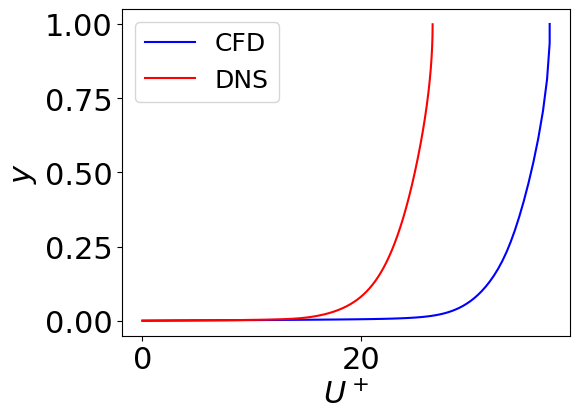

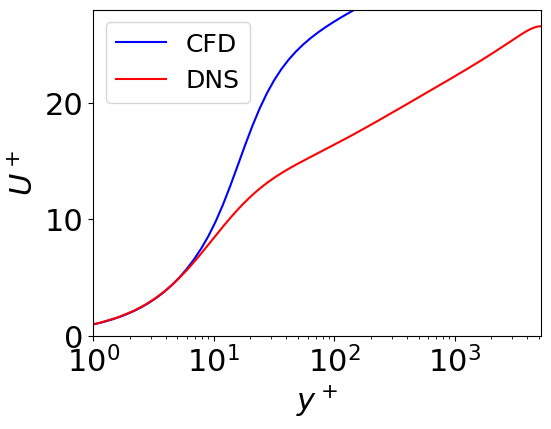

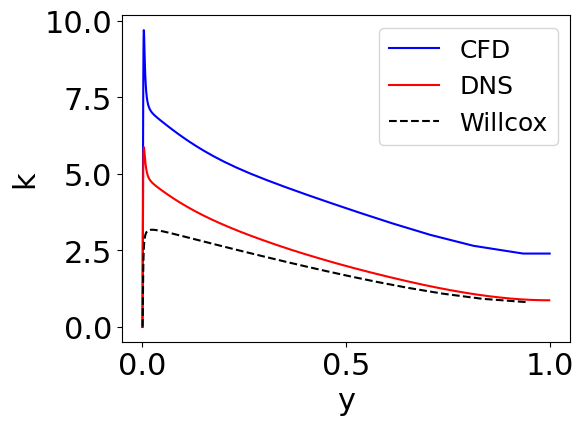

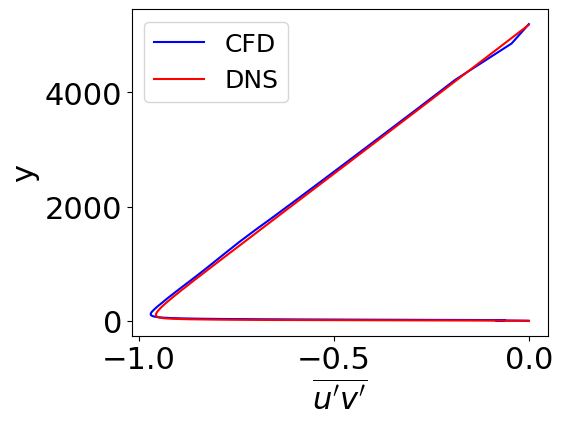

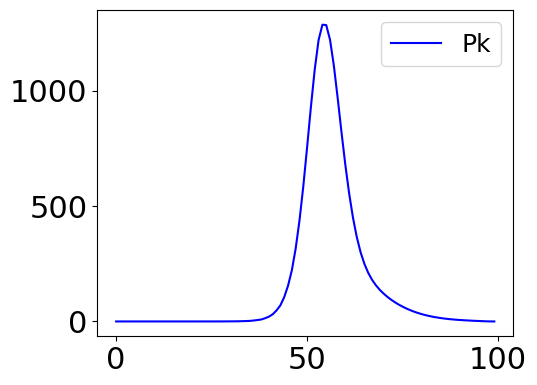

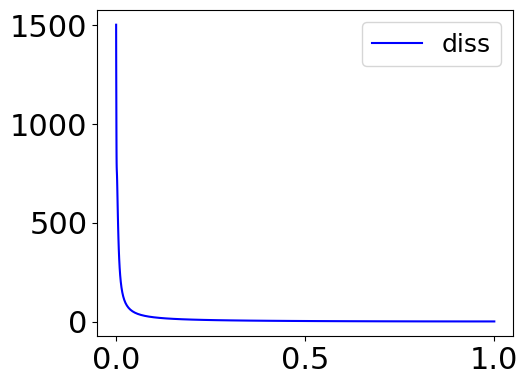

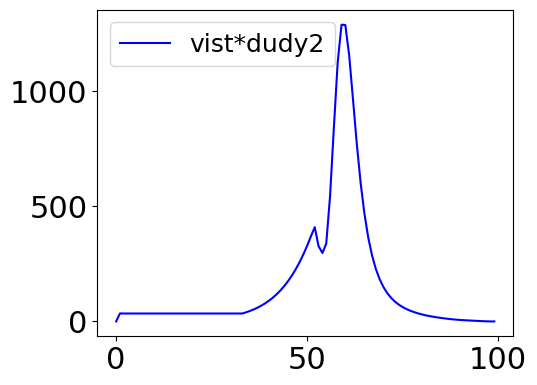

In [7]:
# plot u
fig1,ax1 = plt.subplots()
plt.subplots_adjust(left=0.20,bottom=0.20)
plt.plot(u,yp,'b-',label="CFD")
plt.plot(u_DNS,y_DNS,'r-',label="DNS")
plt.xlabel("$U^+$")
plt.ylabel("$y$")
plt.legend(loc="best",prop=dict(size=18))
# plt.savefig('u_5200-NN-kom.png')

# plot u log-scale
fig1,ax1 = plt.subplots()
plt.subplots_adjust(left=0.20,bottom=0.20)
ustar=tau_w[ntot]**0.5
uplus=u/ustar
plt.semilogx(yp*ustar/viscos,uplus,'b-',label="CFD")
plt.semilogx(yplus_DNS,u_DNS,'r-',label="DNS")
plt.ylabel("$U^+$")
plt.xlabel("$y^+$")
plt.axis([1, 5200, 0, 28])
plt.legend(loc="best",prop=dict(size=18))
# plt.savefig('u_log-5200-NN-kom.png')

# # plot visc
# fig1,ax1 = plt.subplots()
# plt.subplots_adjust(left=0.20,bottom=0.20)
# plt.plot(vist/viscos,yp,'b-',label=r"$k-\varepsilon$")
# plt.legend(loc="best",prop=dict(size=18))
# plt.xlabel(r'$\nu_t/\nu$')
# plt.ylabel('y')
# # plt.savefig('vis_5200-NN-kom.png')

# # plot eps
# fig1,ax1 = plt.subplots()
# plt.subplots_adjust(left=0.20,bottom=0.20)
# plt.plot(eps,yp,'b-',label=r"$k-\varepsilon$")
# plt.legend(loc="best",prop=dict(size=18))
# plt.xlabel(r'$\varepsilon$')
# plt.ylabel('y')
# # plt.savefig('eps_5200-NN-kom.png')

# plot k
fig1,ax1 = plt.subplots()
plt.subplots_adjust(left=0.20,bottom=0.20)
plt.plot(yp,k,'b-',label="CFD")
plt.plot(y_DNS,k_DNS,'r-',label="DNS")
plt.plot(y_kom,k_kom,'k--',label='Willcox')
plt.legend(loc="best",prop=dict(size=18))
plt.ylabel('k')
plt.xlabel('y')
# plt.savefig('k_5200-NN-kom.png')

# plot uv
fig1,ax1 = plt.subplots()
plt.subplots_adjust(left=0.25,bottom=0.20)
uv = -vist*dudy
plt.plot(uv,yp*ustar/viscos,'b-',label="CFD")
plt.plot(uvDNS,yplus_DNS,'r-',label="DNS")
plt.legend(loc="best",prop=dict(size=18))
plt.xlabel(r"$\overline{u'v'}$")
plt.ylabel('y')
# plt.savefig('uv_5200-NN-kom.png')

# plot Pk_DNS
fig1,ax1 = plt.subplots()
plt.subplots_adjust(left=0.25,bottom=0.20)
uv = -vist*dudy
plt.plot(Pk_DNS_interp,'b-',label="Pk")
plt.legend(loc="best",prop=dict(size=18))

# plot diss_DNS
fig1,ax1 = plt.subplots()
plt.subplots_adjust(left=0.25,bottom=0.20)
uv = -vist*dudy
plt.plot(yp,diss_DNS_interp,'b-',label="diss")
plt.legend(loc="best",prop=dict(size=18))

# plot vist*dudy2
fig1,ax1 = plt.subplots()
plt.subplots_adjust(left=0.25,bottom=0.20)
uv = -vist*dudy
plt.plot(vist*dudy2,'b-',label="vist*dudy2")
plt.legend(loc="best",prop=dict(size=18))

plt.show(block=True)

